In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv


In [2]:
data = pd.read_csv("/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv")


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
data.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [5]:
data.shape

(100000, 32)

In [6]:
data.columns

Index(['person_id', 'age', 'gender', 'occupation', 'bmi', 'country',
       'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage',
       'deep_sleep_percentage', 'sleep_latency_mins',
       'wake_episodes_per_night', 'caffeine_mg_before_bed',
       'alcohol_units_before_bed', 'screen_time_before_bed_mins',
       'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score',
       'work_hours_that_day', 'chronotype', 'mental_health_condition',
       'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work',
       'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season',
       'day_type', 'cognitive_performance_score', 'sleep_disorder_risk',
       'felt_rested'],
      dtype='object')

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [8]:
data.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [9]:
data.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

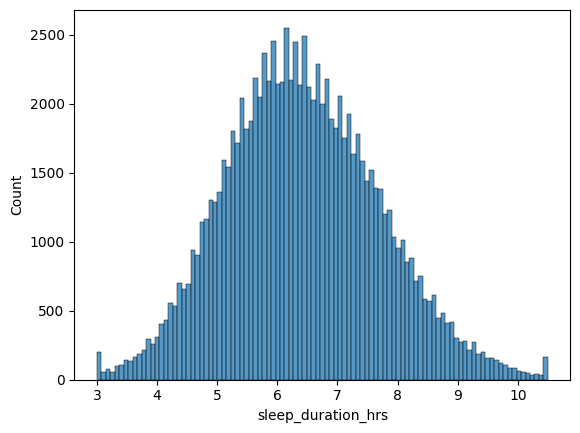

In [10]:
sns.histplot(data['sleep_duration_hrs'])
plt.show()

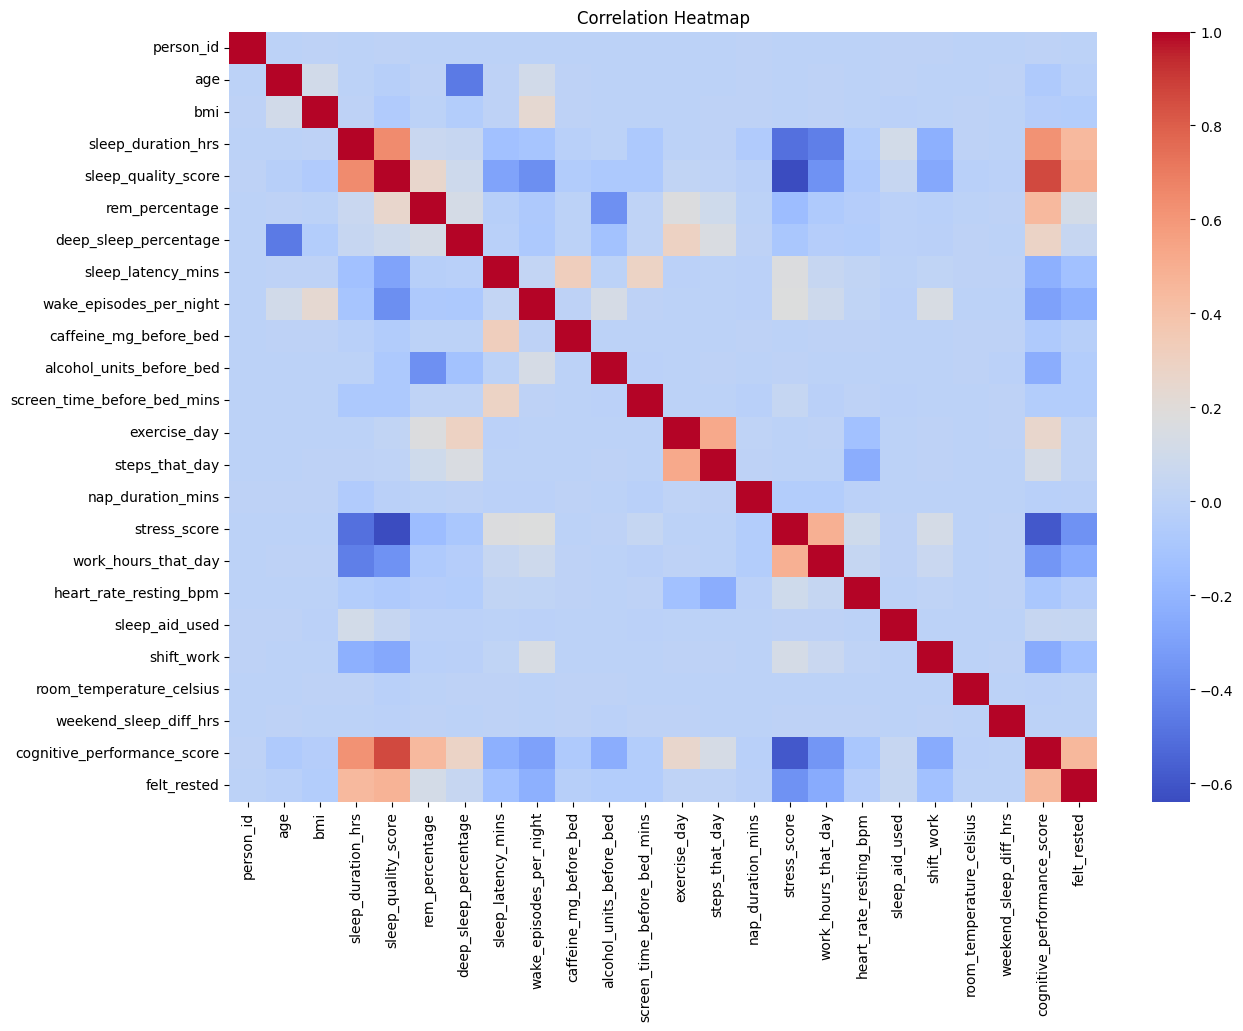

In [11]:
numeric_df = data.select_dtypes(include='number')
plt.figure(figsize=(14,10))
sns.heatmap(numeric_df.corr(), cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [12]:
X = data.drop("sleep_quality_score", axis=1)   
y = data["sleep_quality_score"] 

In [13]:
X = pd.get_dummies(X, drop_first=True)

In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
y_pred = rf_model.predict(X_test)

In [18]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.8690523475479841
RMSE: 0.548268530284203


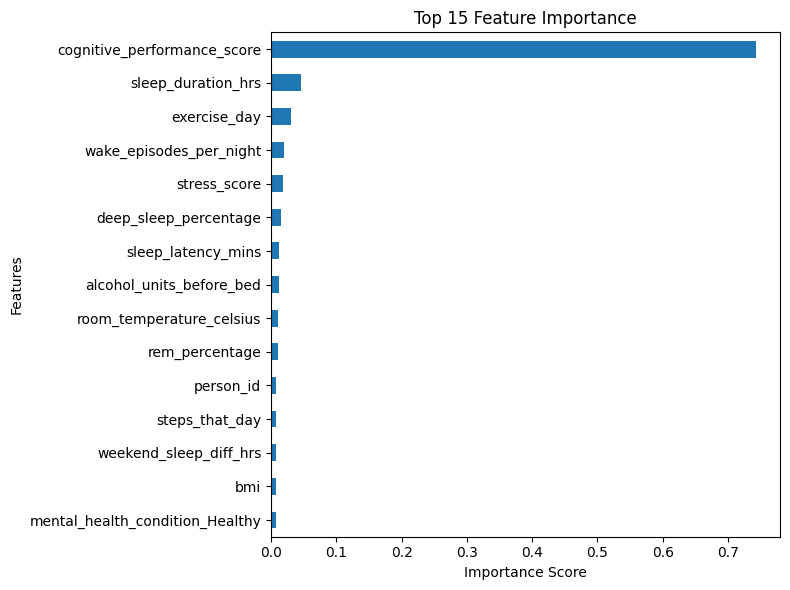

In [19]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importance.sort_values(ascending=False).head(15)
plt.figure(figsize=(8,6))
top_features.sort_values().plot(kind='barh')
plt.title("Top 15 Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()